Import Data

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
file_path = "Rata-rata gaji tahunan per sektor 2015-2025 (1).xlsx"

df = pd.read_excel(file_path)

df.head()

,Sektor,Rata-rata Gaji Tahunan,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,2015,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
1,A,1265700,1542341.0,1761803.0,1824738.0,2041145.0,1989195.0,1951747.0,2081590.0,2218558.0,2321879.0,2393809.0
2,B,3610765,4222708.0,4358002.0,4381899.0,4902251.0,4788831.0,4312355.0,4571895.0,4693515.0,5086714.0,5034904.0
3,C,1730596,2180973.0,2547268.0,2591425.0,2748055.0,2726340.0,2767730.0,2918070.0,3083971.0,3136317.0,3180362.0
4,D,2710527,3136878.0,4023235.0,3495366.0,3902034.0,3861682.0,3913233.0,4549862.0,4309407.0,4842654.0,5056759.0


In [48]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(68, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sektor                  36 non-null     object 
 1   Rata-rata Gaji Tahunan  37 non-null     object 
 2   Unnamed: 2              19 non-null     float64
 3   Unnamed: 3              19 non-null     float64
 4   Unnamed: 4              19 non-null     float64
 5   Unnamed: 5              19 non-null     float64
 6   Unnamed: 6              19 non-null     float64
 7   Unnamed: 7              19 non-null     float64
 8   Unnamed: 8              19 non-null     float64
 9   Unnamed: 9              19 non-null     float64
 10  Unnamed: 10             19 non-null     float64
 11  Unnamed: 11             19 non-null     float64
dtypes: float64(10), object(2)
memory usage: 6.5+ KB
None
Sektor                    32
Rata-rata Gaji Tahunan    31
Unnamed: 2                49
U

Cleaning

In [49]:
new_columns = ['Sektor'] + df.iloc[0, 1:].tolist()

df.columns = new_columns

df = df.drop(0).reset_index(drop=True)

df.head()

,Sektor,2015,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
0,A,1265700,1542341.0,1761803.0,1824738.0,2041145.0,1989195.0,1951747.0,2081590.0,2218558.0,2321879.0,2393809.0
1,B,3610765,4222708.0,4358002.0,4381899.0,4902251.0,4788831.0,4312355.0,4571895.0,4693515.0,5086714.0,5034904.0
2,C,1730596,2180973.0,2547268.0,2591425.0,2748055.0,2726340.0,2767730.0,2918070.0,3083971.0,3136317.0,3180362.0
3,D,2710527,3136878.0,4023235.0,3495366.0,3902034.0,3861682.0,3913233.0,4549862.0,4309407.0,4842654.0,5056759.0
4,E,1537601,2336472.0,3180252.0,2754096.0,2498009.0,2574084.0,2677455.0,2703749.0,2879474.0,2820729.0,2870748.0


In [50]:
df = df.dropna(subset=['Sektor'])

In [51]:
numeric_cols = df.columns[1:]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

Missing Value

In [52]:
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [53]:
df.isnull().sum()

,0
Sektor,0
2015,0
2016.0,0
2017.0,0
2018.0,0
2019.0,0
2020.0,0
2021.0,0
2022.0,0
2023.0,0


Penanganan

In [27]:
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [28]:
raw_df.isnull().sum()

,0
Sektor,0
2015,0
2016.0,0
2017.0,0
2018.0,0
2019.0,0
2020.0,0
2021.0,0
2022.0,0
2023.0,0


Penanganan Outlier

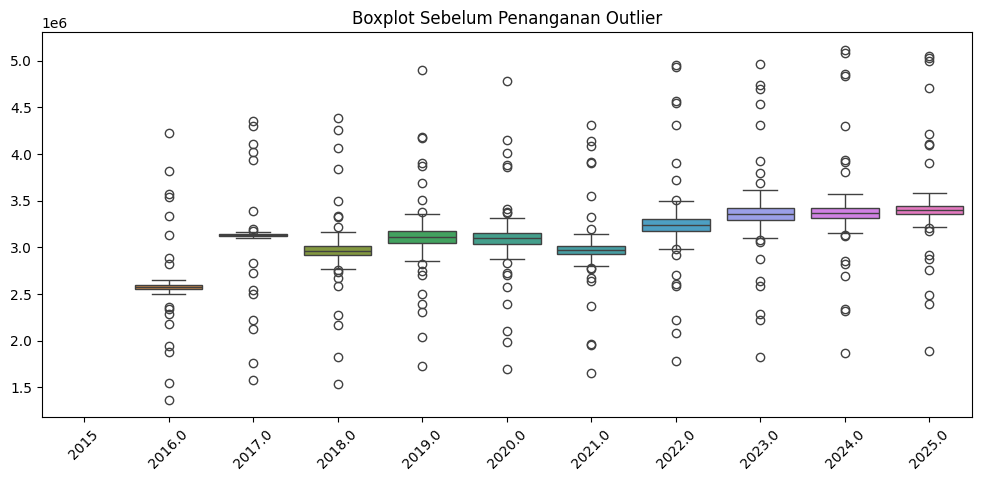

In [54]:
plt.figure(figsize=(12,5))

sns.boxplot(data=df[numeric_cols])

plt.title("Boxplot Sebelum Penanganan Outlier")
plt.xticks(rotation=45)

plt.show()

In [65]:
winsor_df = raw_df.copy()

for col in numeric_cols:
    Q1 = winsor_df[col].quantile(0.25)
    Q3 = winsor_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    winsor_df[col] = np.where(
        winsor_df[col] < lower,
        lower,
        winsor_df[col]
    )

    winsor_df[col] = np.where(
        winsor_df[col] > upper,
        upper,
        winsor_df[col]
    )

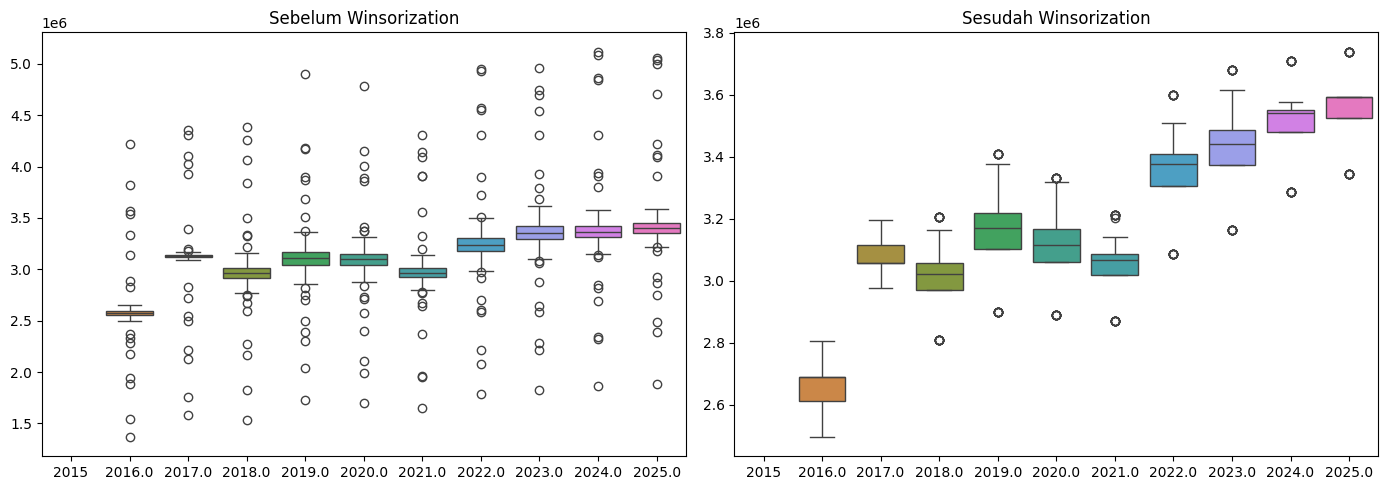

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Sebelum
sns.boxplot(data=df[numeric_cols], ax=axes[0])
axes[0].set_title("Sebelum Winsorization")

# Sesudah
sns.boxplot(data=winsor_df[numeric_cols], ax=axes[1])
axes[1].set_title("Sesudah Winsorization")

plt.tight_layout()
plt.show()

EDA

In [68]:
winsor_df.describe()

,2015,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
count,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01
mean,2.328731e+06,2.664564e+06,3.073970e+06,3.013707e+06,3.159540e+06,3.113022e+06,3.051303e+06,3.354467e+06,3.429546e+06,3.515996e+06,3.562300e+06
std,3.979274e+04,1.097940e+05,7.723310e+04,1.406477e+05,1.801248e+05,1.578395e+05,1.206045e+05,1.794055e+05,1.833287e+05,1.498802e+05,1.401734e+05
min,2.273967e+06,2.495411e+06,2.974888e+06,2.809651e+06,2.899121e+06,2.890189e+06,2.870768e+06,3.085333e+06,3.162331e+06,3.286564e+06,3.345409e+06
25%,2.315859e+06,2.611012e+06,3.058044e+06,2.969105e+06,3.101872e+06,3.059410e+06,3.016932e+06,3.304221e+06,3.372196e+06,3.477945e+06,3.523730e+06
50%,2.327202e+06,2.688079e+06,3.058044e+06,3.022256e+06,3.169456e+06,3.115816e+06,3.065653e+06,3.377183e+06,3.442150e+06,3.541739e+06,3.591199e+06
75%,2.341821e+06,2.688079e+06,3.113482e+06,3.057088e+06,3.217701e+06,3.166235e+06,3.084282e+06,3.406943e+06,3.485095e+06,3.550369e+06,3.591199e+06
max,2.385678e+06,2.803679e+06,3.196638e+06,3.205550e+06,3.408849e+06,3.331862e+06,3.212389e+06,3.599909e+06,3.678754e+06,3.708652e+06,3.738672e+06


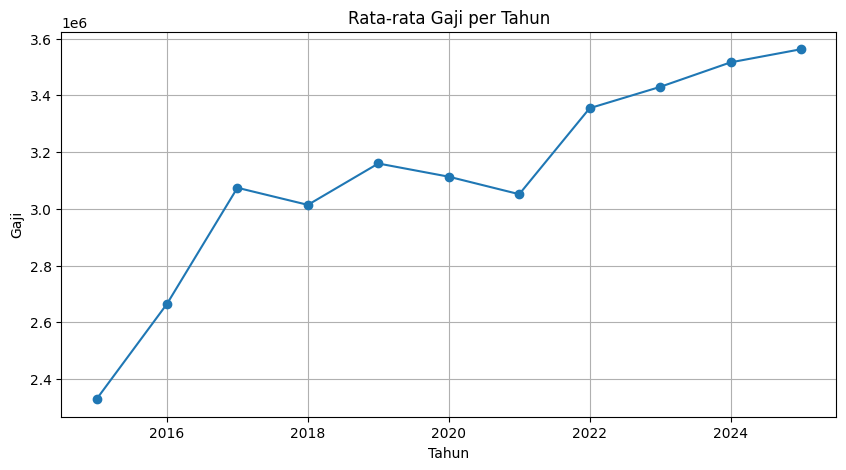

In [69]:
avg_salary = winsor_df[numeric_cols].mean()

plt.figure(figsize=(10,5))

plt.plot(
    avg_salary.index,
    avg_salary.values,
    marker='o'
)

plt.title("Rata-rata Gaji per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Gaji")
plt.grid(True)

plt.show()

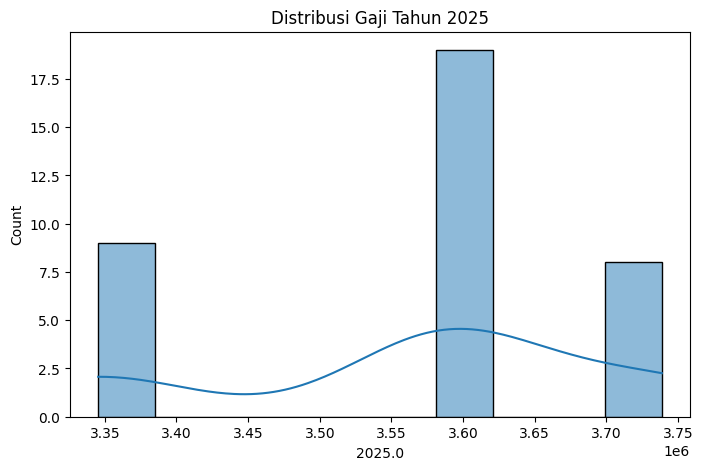

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(
    winsor_df[2025],
    bins=10,
    kde=True
)

plt.title("Distribusi Gaji Tahun 2025")

plt.show()

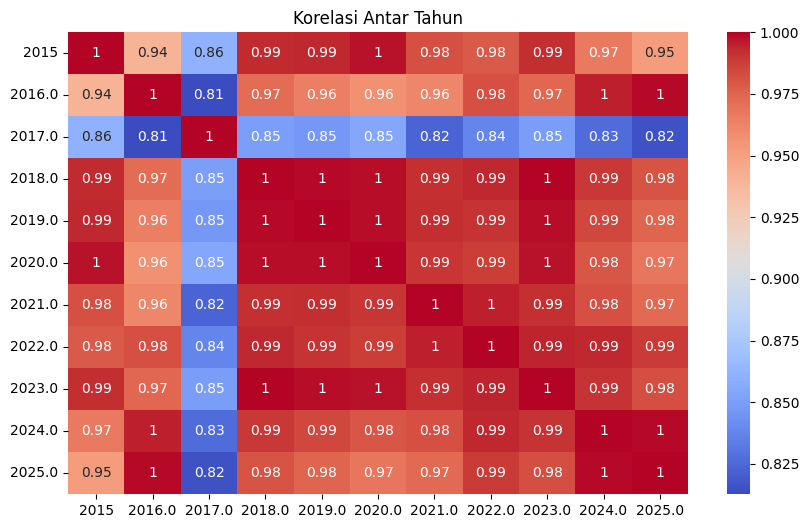

In [71]:
plt.figure(figsize=(10,6))

sns.heatmap(
    winsor_df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Korelasi Antar Tahun")

plt.show()

In [72]:
top_salary = winsor_df[['Sektor', 2025]] \
    .sort_values(by=2025, ascending=False)

top_salary.head(10)

,Sektor,2025.0
1,B,3.738672e+06
3,D,3.738672e+06
11,L,3.738672e+06
7,H,3.738672e+06
13,O,3.738672e+06
12,"M, N",3.738672e+06
10,K,3.738672e+06
9,J,3.738672e+06
59,J,3.591199e+06
60,K,3.591199e+06


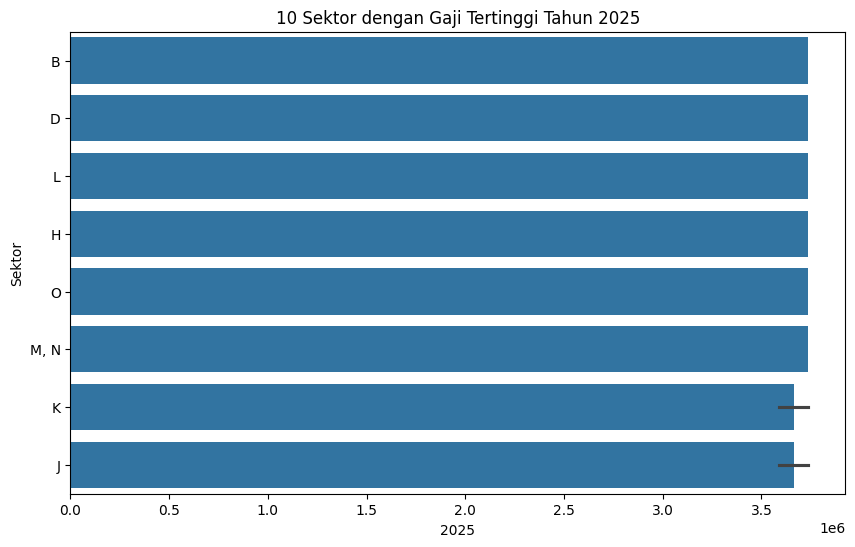

In [73]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_salary.head(10),
    x=2025,
    y='Sektor'
)

plt.title("10 Sektor dengan Gaji Tertinggi Tahun 2025")

plt.show()

In [74]:
winsor_df['Growth_%'] = (
    (winsor_df[2025] - winsor_df[2015])
    / winsor_df[2015]
) * 100

In [75]:
growth_df = winsor_df[
    ['Sektor', 'Growth_%']
].sort_values(by='Growth_%', ascending=False)

growth_df.head()

,Sektor,Growth_%
1,B,56.713188
3,D,56.713188
11,L,56.713188
7,H,56.713188
13,O,56.713188


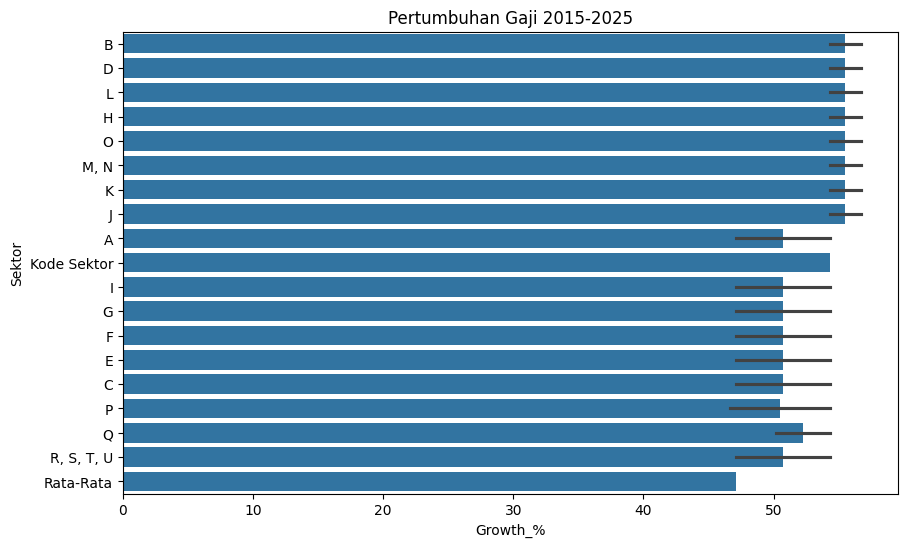

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=growth_df,
    x='Growth_%',
    y='Sektor'
)

plt.title("Pertumbuhan Gaji 2015-2025")

plt.show()

In [77]:
long_df = winsor_df.melt(
    id_vars='Sektor',
    var_name='Tahun',
    value_name='Gaji'
)

long_df.head()

,Sektor,Tahun,Gaji
0,A,2015,2273967.25
1,B,2015,2385678.25
2,C,2015,2273967.25
3,D,2015,2385678.25
4,E,2015,2273967.25


In [78]:
winsor_df.to_csv(
    "gaji_clean_fix.csv",
    index=False
)